In [2]:
# Cell 1 — setup
%load_ext autoreload
%autoreload 2
import sys
sys.path.append(os.path.abspath('..'))
import numpy as np
import pandas as pd
import os
import plotly.graph_objects as go
import warnings
from statsmodels.tools.sm_exceptions import ValueWarning
warnings.filterwarnings('ignore')
warnings.filterwarnings('ignore', category=ValueWarning)

from scripts.data_loader import MacroDataLoader
from scripts.validator import WalkForwardValidator, ARIMAValidator
from scripts.evaluator import ModelEvaluator
from xgboost import XGBRegressor
from sklearn.linear_model import ElasticNet

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
# Cell 2 — load data once, all models share same X and y
loader = MacroDataLoader('../data/master_data1.csv')
loader.load()
loader.build_lag_features()
X, y = loader.get_feature_matrix()
print(X.shape, y.shape)

(160, 6) (160,)


In [3]:
# Cell 3 — run all models
# ARIMA
arima_validator = ARIMAValidator(y, order=(3,0,0), test_start='2022-01-01')
arima_validator.run()

# ARIMAX
exog = X[['crude_lag1', 'inr_lag1', 'm3_lag12']]
arimax_validator = ARIMAValidator(y, order=(3,0,0), 
                                  test_start='2022-01-01', 
                                  exog=exog)
arimax_validator.run()

# XGBoost — best params confirmed in notebook 04
best_params_xgb = {
    'colsample_bytree': 0.5, 'learning_rate': 0.05,
    'max_depth': 2, 'min_child_weight': 5,
    'n_estimators': 100, 'subsample': 0.6
}
validator_xgb = WalkForwardValidator(
    XGBRegressor(**best_params_xgb, random_state=42), 
    X, y, test_start='2022-01-01'
)
validator_xgb.run()

# ElasticNet — best params confirmed in notebook 05
best_params_en = {'alpha': 0.01, 'l1_ratio': 1.0}
validator_en = WalkForwardValidator(
    ElasticNet(**best_params_en, max_iter=10000),
    X, y, test_start='2022-01-01'
)
validator_en.run()

print("All models done")

All models done


In [4]:
# Cell 4 — collect all results in evaluator
evaluator = ModelEvaluator()
evaluator.add_model('ARIMA', arima_validator.actuals, arima_validator.predictions)
evaluator.add_model('ARIMAX', arimax_validator.actuals, arimax_validator.predictions)
evaluator.add_model('XGBoost', validator_xgb.actuals, validator_xgb.predictions)
evaluator.add_model('ElasticNet', validator_en.actuals, validator_en.predictions)

print(evaluator.get_comparison_table())

        model    rmse     mae
0       ARIMA  0.7024  0.5397
3  ElasticNet  0.7213  0.5458
1      ARIMAX  0.7246  0.5438
2     XGBoost  0.8390  0.6607


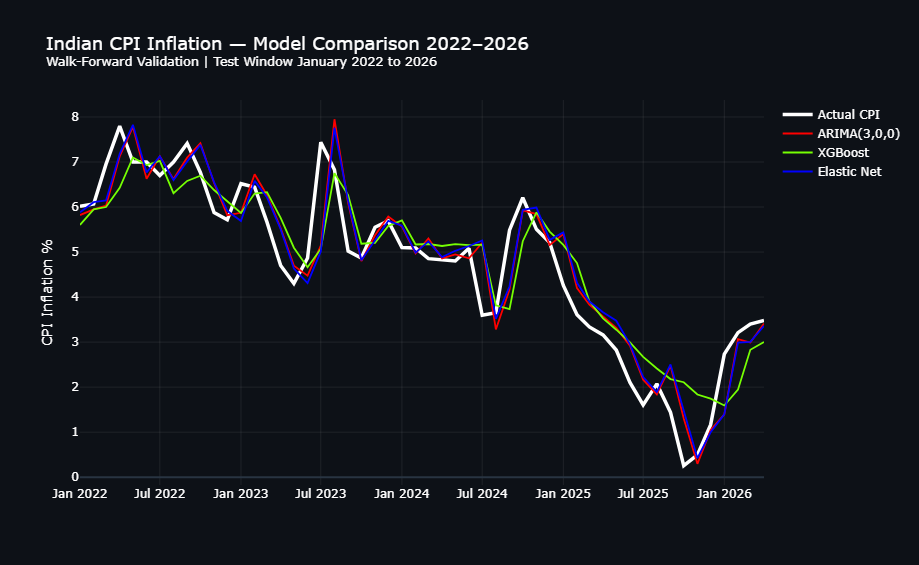

In [6]:
# Cell 5 — comparison chart
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=arima_validator.actuals.index,
    y=arima_validator.actuals.values,
    name='Actual CPI',
    line=dict(color='white', width=3.5)
))
fig.add_trace(go.Scatter(
    x=arima_validator.predictions.index,
    y=arima_validator.predictions.values,
    name='ARIMA(3,0,0)',
    line=dict(color='red', width=1.8)
))
fig.add_trace(go.Scatter(
    x=validator_xgb.predictions.index,
    y=validator_xgb.predictions.values,
    name='XGBoost',
    line=dict(color='#76FF03', width=1.8)
))
fig.add_trace(go.Scatter(
    x=validator_en.predictions.index,
    y=validator_en.predictions.values,
    name='Elastic Net',
    line=dict(color='blue', width=1.8)
))

fig.update_layout(
    title=dict(
        text='Indian CPI Inflation — Model Comparison 2022–2026<br>'
             '<sup>Walk-Forward Validation | Test Window January 2022 to 2026</sup>',
        font=dict(size=18, color='white'),
        x=0.05
    ),
    paper_bgcolor='#0D1117',
    plot_bgcolor='#0D1117',
    template='plotly_dark',
    height=550,
    width=1000,
    font=dict(color='white'),
    yaxis=dict(
        title='CPI Inflation %',
        gridcolor='rgba(255,255,255,0.08)'
    ),
    xaxis=dict(gridcolor='rgba(255,255,255,0.08)')
)

fig.show()